In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from helpers.collection_of_experiments import CollectionOfExperiments
from helpers.plot_helpers import *
from helpers.computational_tools import remesh, select_LatLon, Lk_error, x_coord, y_coord, gaussian_remesh
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cmocean
import os
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore")

In [2]:
ds = CollectionOfExperiments.init_folder('/scratch/pp2681/mom6/Feb2022/bare', additional_subfolder='output')

In [3]:
directory = "/scratch/pp2681/mom6/Apr2023/R4-sensitivity"
for name in os.listdir(directory):
    ds += CollectionOfExperiments.init_folder(os.path.join(directory,name), additional_subfolder='output', prefix=name)

Error, cannot find files in folder/scratch/pp2681/mom6/Apr2023/R4-sensitivity/calibration/Cs-0.074-ZB-1.33/output
Error, cannot find files in folder/scratch/pp2681/mom6/Apr2023/R4-sensitivity/calibration/zip/output


In [4]:
for exp in ['R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8']:
    ds.remesh('R64', exp)

Experiment R64 coarsegrained to R2 is created. Its identificator=R64_R2
Experiment R64 coarsegrained to R3 is created. Its identificator=R64_R3
Experiment R64 coarsegrained to R4 is created. Its identificator=R64_R4
Experiment R64 coarsegrained to R5 is created. Its identificator=R64_R5
Experiment R64 coarsegrained to R6 is created. Its identificator=R64_R6
Experiment R64 coarsegrained to R7 is created. Its identificator=R64_R7
Experiment R64 coarsegrained to R8 is created. Its identificator=R64_R8


In [5]:
def error_ssh(exp):
    return Lk_error(ds[exp].ssh_mean,ds['R64_R4'].ssh_mean)[0]

In [6]:
def error_2d(error_function = error_ssh, prefix='ZB-clean'):
    ZBs = sorted([float(exp.split('-')[-1]) for exp in ds.exps if f'{prefix}-Cs-0.03' in exp])
    Css = sorted(set([float(exp.split('-')[-3]) for exp in ds.exps if f'{prefix}-Cs-' in exp]))
    
    error = np.zeros((len(ZBs), len(Css)))
    for i, Cs in enumerate(Css):
        for j, ZB in enumerate(ZBs):
            try:
                error[j,i] = error_function(f'{prefix}-Cs-{Cs:.2f}-ZB-{ZB}')
            except:
                error[j,i] = np.nan
    error = xr.DataArray(error, dims=['ZB', 'Cs'], coords={'Cs': Css, 'ZB': ZBs})
    return error

In [7]:
ssh = {'v0': 0.26709399, 'vmin': 0.0, 'error_function': error_ssh, 
           'cbar_ticks': np.arange(0.0,0.7,0.05), 
           'cbar_extend': 'neither', 'cbar_label': 'RMSE in \ntime-mean SSH, $\mathrm{m}$'};

In [8]:
def constrain_optimization(e):
    #shape of e is ZB x Cs
    ee = e.copy()
    for j in range(e.shape[1]):
        for i in range(e.shape[0]):
            if np.isnan(e[i,j]):
                ee[i:,j] = np.nan
    return ee    

In [9]:
def plot_panels(exps, labels, v0, vmin, error_function, color='w', cbar_ticks=None, cbar_extend='none', cbar_label=''):
    default_rcParams({'axes.formatter.limits': (-3,3)})
    fig = plt.figure(figsize=(3*len(exps),4))
    vspread = v0-vmin
    vmax = v0+vspread

    for col in range(len(exps)):
        label=labels[col]
        exp=exps[col]
        plt.subplot(1,len(exps),col+1)
        e = error_2d(error_function = error_function, prefix=exp)
        X,Y = np.meshgrid(e.Cs, e.ZB)
        em = np.ma.masked_invalid(e)
        im = plt.pcolor(X,Y,em,vmin=vmin,vmax=vmax,cmap='RdBu_r')
        # https://stackoverflow.com/questions/35905393/python-leave-numpy-nan-values-from-matplotlib-heatmap-and-its-legend
        plt.gca().patch.set(hatch='OO', edgecolor='black')
        
        #im = e.plot(cmap='RdBu_r', add_colorbar=False, vmin=vmin, vmax=vmax)
        cb = plt.colorbar(im, fraction=0.3, pad=0.05, aspect=15, ticks=cbar_ticks, extend=cbar_extend)
        cb.set_label(cbar_label, fontsize=16, labelpad=10)
        if col<len(exps)-1:
            cb.ax.set_yticklabels(['']*len(cbar_ticks))
            cb.set_label('')
            
        idx_opt = constrain_optimization(e).argmin(dim='ZB')
        if len(e.Cs) == 3:
            markers = ['v', 'o', 's']
        else:
            markers = ['*', 'v', 'o', 's']
        
        # for marker, Cs in zip(markers,idx_opt.Cs):
        #     idx = idx_opt.sel(Cs=Cs)
        #     plt.plot(Cs,e.ZB[idx], marker=marker, markeredgecolor=color, markerfacecolor='none', markersize=10, markeredgewidth=2, clip_on=False)
        #     cb.ax.plot(0.5,e.sel(Cs=Cs).isel(ZB=idx),marker=marker,markeredgecolor=color, markerfacecolor='none', markersize=10, markeredgewidth=2)
        #     plt.plot(Cs,0,marker=marker,markeredgecolor='k', markerfacecolor='none', markersize=7, markeredgewidth=1, clip_on=False)
        #     cb.ax.plot(0.5,e.sel(ZB=0.0,Cs=Cs),marker=marker,markeredgecolor='k', markerfacecolor='none', markersize=7, markeredgewidth=1)
        
#         for Cs in e.Cs:
#             for ZB in e.ZB:
#                 if np.isnan(e.sel(Cs=Cs,ZB=ZB)):
#                     plt.plot(Cs,ZB,marker='*',color='k')

        plt.xticks(e.Cs.values, rotation=60)
        if len(e.ZB) > 16:
            plt.yticks(e.ZB.values[::2])
        else:
            plt.yticks(e.ZB.values)
            
        plt.xlabel('')
        if col==0:
            plt.ylabel('ZB scaling coefficient, $\gamma$', fontsize=20)
        else:
            plt.ylabel('')
        plt.title(label)
    fig.text(0.5, -0.1, 'Smagorinsky coefficient $C_S$', ha='center', fontsize=20)
    

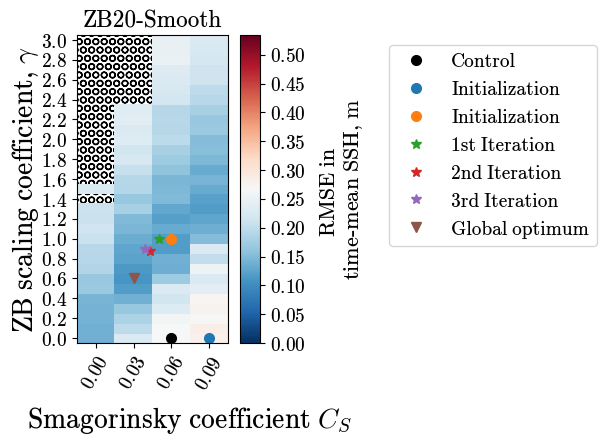

In [32]:
plot_panels(['ZB-stress-pass-4-sel-1'], ['ZB20-Smooth'], **ssh)
plt.plot(0.06,0.0,marker='o', markersize=7, label='Control', color='k', ls='')
plt.plot(0.09,0.0,marker='o', markersize=7, label='Initialization', ls='')
plt.plot(0.06,1.0,marker='o', markersize=7, label='Initialization', ls='')
plt.plot(0.05,1.0,marker='*', markersize=7, label='1st Iteration', ls='')
plt.plot(0.043,0.88,marker='*', markersize=7, label='2nd Iteration', ls='')
plt.plot(0.039,0.9,marker='*', markersize=7, label='3rd Iteration', ls='')
plt.plot(0.03,0.6,marker='v', markersize=7, label='Global optimum', ls='')
plt.legend(bbox_to_anchor=(2,1))

In [22]:
er2d = error_2d(error_ssh, 'ZB-stress-pass-4-sel-1').compute()

In [29]:
# Global optimum point
er2d.min()

<xarray.DataArray ()> Size: 8B
array(0.10988918)

In [30]:
# Indices of global optimum
er2d.sel(Cs=0.03, ZB=0.6)

<xarray.DataArray ()> Size: 8B
array(0.10988918)
Coordinates:
    Cs       float64 8B 0.03
    ZB       float64 8B 0.6

# Broyden iteration
We are solving the inverse problem
$$G(u) = y-y_{obs}\approx0$$
That is
$$
||G(u)-y_{obs}||_2^2 \to \min_{u}
$$

Here, vector of parameters are eddy viscosity and strength of ZB parameterization
$$
u = [C_{S}, \gamma]
$$
vectors $y$ and $y_{obs}$ are 10-year averages of SSH flattened into vector of length $7040$.

We start with constructing Jacobian $J\in\mathbb{R}^{7040 \times 2}$ with finite differences:
$$
J[:,0] = \frac{\delta G(u)}{\delta C_S}
$$
$$
J[:,1] = \frac{\delta G(u)}{\delta \gamma}
$$

Then we initialize inverse Jacobian:
$$
H = J^{+}
$$

And do one Broyden iteration:
$$
u = u - H(G(u)-y_{obs})
$$

## First iteration

In [23]:
J = np.zeros((7040,2))

J[:,0] = ((ds['ZB-stress-pass-4-sel-1-Cs-0.09-ZB-0.0'].ssh_mean - ds['ZB-stress-pass-4-sel-1-Cs-0.06-ZB-0.0'].ssh_mean) / (0.09-0.06)).values.ravel()
J[:,1] = ((ds['ZB-stress-pass-4-sel-1-Cs-0.06-ZB-1.0'].ssh_mean - ds['ZB-stress-pass-4-sel-1-Cs-0.06-ZB-0.0'].ssh_mean) / (1.0-0.0)).values.ravel()

In [24]:
J0 = J

In [289]:
# Alternative initialization
H0 = J.T*0
dy = (ds['ZB-stress-pass-4-sel-1-Cs-0.09-ZB-0.0'].ssh_mean - ds['ZB-stress-pass-4-sel-1-Cs-0.06-ZB-0.0'].ssh_mean).values.ravel()
du = np.array([0.03,0])
H0 += np.outer(du-H0@dy, dy) / np.dot(dy,dy)

dy = (ds['ZB-stress-pass-4-sel-1-Cs-0.06-ZB-1.0'].ssh_mean - ds['ZB-stress-pass-4-sel-1-Cs-0.06-ZB-0.0'].ssh_mean).values.ravel()
du = np.array([0,1.0])
H0 += np.outer(du-H0@dy, dy) / np.dot(dy,dy)

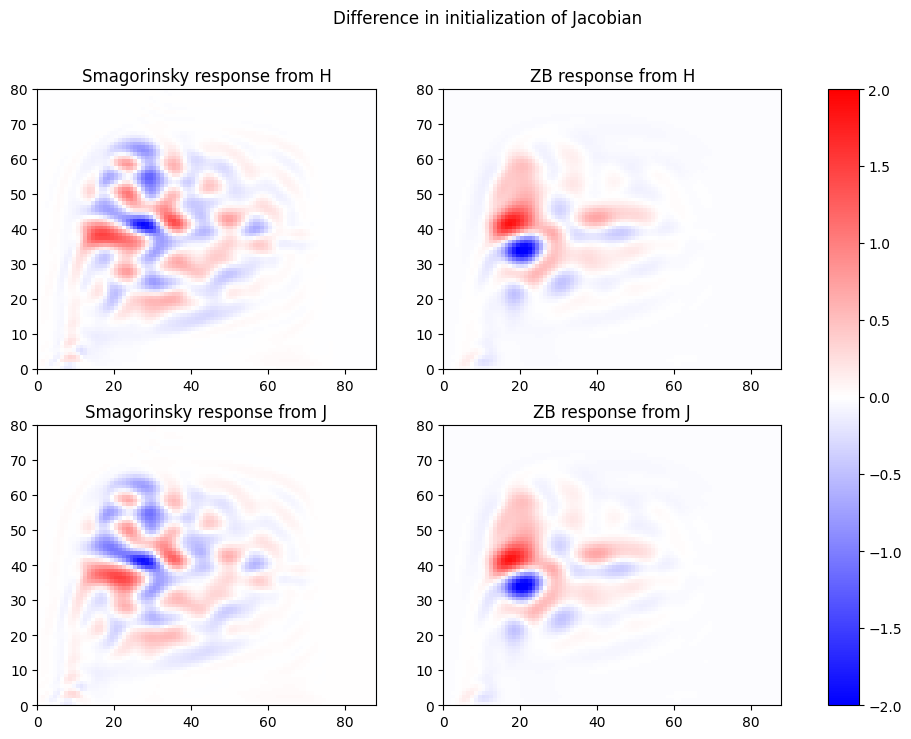

In [290]:
plt.figure(figsize=(12,8))
kw = dict(vmin=-2,vmax=2,cmap='bwr')
plt.subplot(2,2,1)
plt.pcolormesh(0.2*np.linalg.pinv(H0)[:,0].reshape([80,88]), **kw)
plt.title('Smagorinsky response from H')
plt.subplot(2,2,2)
plt.pcolormesh(np.linalg.pinv(H0)[:,1].reshape([80,88]), **kw)
plt.title('ZB response from H')

plt.subplot(2,2,3)
plt.pcolormesh(0.2*J[:,0].reshape([80,88]), **kw)
plt.title('Smagorinsky response from J')
plt.subplot(2,2,4)
plt.pcolormesh(J[:,1].reshape([80,88]), **kw)
plt.title('ZB response from J')

plt.suptitle('Difference in initialization of Jacobian')


plt.colorbar(ax=plt.gcf().axes)

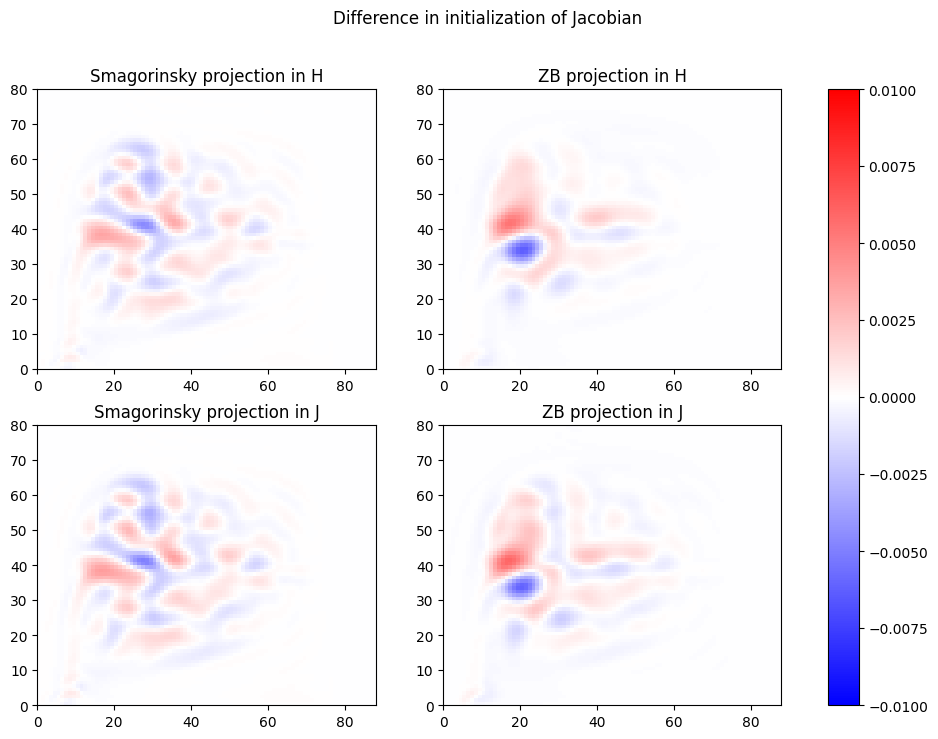

In [291]:
plt.figure(figsize=(12,8))
kw = dict(vmin=-1e-2,vmax=1e-2,cmap='bwr')
plt.subplot(2,2,1)
plt.pcolormesh(5*H0[0,:].reshape([80,88]), **kw)
plt.title('Smagorinsky projection in H')
plt.subplot(2,2,2)
plt.pcolormesh(H0[1,:].reshape([80,88]), **kw)
plt.title('ZB projection in H')

plt.subplot(2,2,3)
plt.pcolormesh(5*np.linalg.pinv(J)[0,:].reshape([80,88]), **kw)
plt.title('Smagorinsky projection in J')
plt.subplot(2,2,4)
plt.pcolormesh(np.linalg.pinv(J)[1,:].reshape([80,88]), **kw)
plt.title('ZB projection in J')

plt.suptitle('Difference in initialization of Jacobian')


plt.colorbar(ax=plt.gcf().axes)

In [292]:
np.linalg.norm(np.linalg.pinv(H0)-J) / np.linalg.norm(J)

0.2910808864771473

In [293]:
H = np.linalg.pinv(J)
print('Singular values of H', np.linalg.svd(H).S)

Singular values of H [0.05629474 0.01011214]


In [294]:
error = (ds['ZB-stress-pass-4-sel-1-Cs-0.06-ZB-0.0'].ssh_mean - ds['R64_R4'].ssh_mean).values.ravel()

In [295]:
u = np.array([0.06, 0.0])

In [296]:
du = - H@error
u += du

In [297]:
# We retain two main digits
for uu in u:
    print(round(uu,3))

0.049
1.068


## A posteriori analysis of quality of iteration

In [298]:
print('Initial loss:', np.sqrt(np.mean(error**2)))
expected_error = error - np.linalg.pinv(H) @ H @ error
print('Expected loss:', np.sqrt(np.mean(expected_error**2)))

Initial loss: 0.267094
Expected loss: 0.11678297854403243


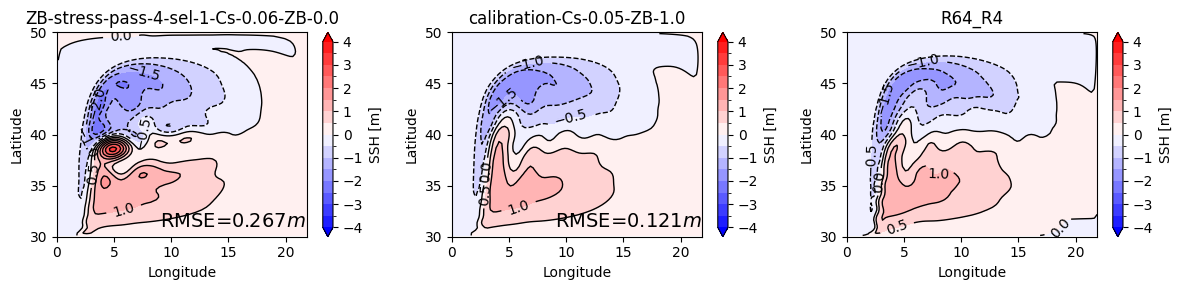

In [299]:
ds.plot_ssh(['ZB-stress-pass-4-sel-1-Cs-0.06-ZB-0.0', 'calibration-Cs-0.05-ZB-1.0', 'R64_R4'])

## Second iteration

In [300]:
du = np.array([0.05, 1.0]) - np.array([0.06, 0.0])

In [301]:
dy = (ds['calibration-Cs-0.05-ZB-1.0'].ssh_mean - ds['ZB-stress-pass-4-sel-1-Cs-0.06-ZB-0.0'].ssh_mean).values.ravel()

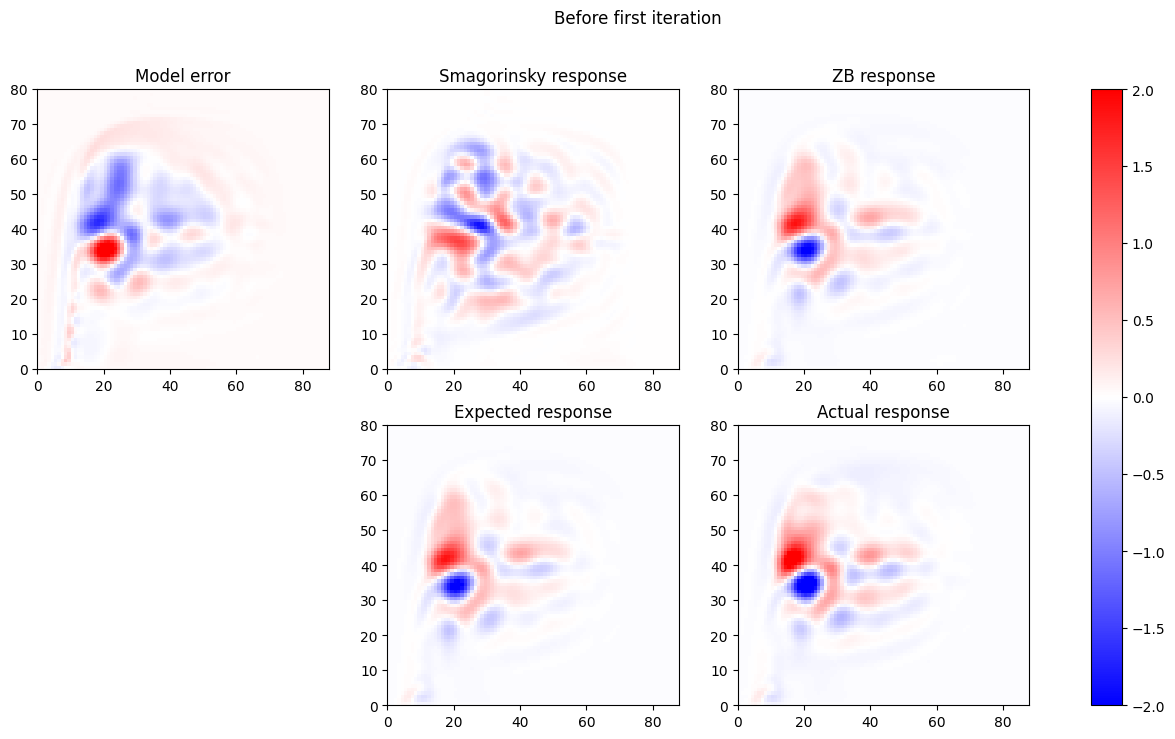

In [302]:
plt.figure(figsize=(16,8))
kw = dict(vmin=-2,vmax=2,cmap='bwr')
plt.subplot(2,3,1)
plt.pcolormesh(error.reshape([80,88]), **kw)
plt.title('Model error')
plt.subplot(2,3,5)
plt.pcolormesh((np.linalg.pinv(H)@du).reshape([80,88]), **kw)
plt.title('Expected response')
plt.subplot(2,3,6)
plt.pcolormesh(dy.reshape([80,88]), **kw)
plt.title('Actual response')

plt.subplot(2,3,2)
plt.pcolormesh(0.2*np.linalg.pinv(H)[:,0].reshape([80,88]), **kw)
plt.title('Smagorinsky response')
plt.subplot(2,3,3)
plt.pcolormesh(np.linalg.pinv(H)[:,1].reshape([80,88]), **kw)
plt.title('ZB response')

plt.suptitle('Before first iteration')


plt.colorbar(ax=plt.gcf().axes)

In [303]:
print(np.linalg.norm(np.outer(du, dy) / np.dot(dy,dy)))
print(np.linalg.norm(np.outer(du-H@dy, dy) / np.dot(dy,dy)))
print(np.linalg.norm(H))

0.042702318838672884
0.00934300547727181
0.05719574232751562


In [304]:
H += np.outer(du-H@dy, dy) / np.dot(dy,dy)

In [305]:
print('Singular values of H', np.linalg.svd(H).S)

Singular values of H [0.04781797 0.01000914]


In [306]:
error = (ds['calibration-Cs-0.05-ZB-1.0'].ssh_mean - ds['R64_R4'].ssh_mean).values.ravel()

In [307]:
u = np.array([0.05, 1.0])

In [308]:
u = u - H@error

In [309]:
# We retain two main digits
print(round(u[0],3))
print(round(u[1],2))

0.043
0.88


## A posteriori analysis of iteration

In [310]:
print('Initial loss:', np.sqrt(np.mean(error**2)))
expected_error = error - np.linalg.pinv(H) @ H @ error
print('Expected loss:', np.sqrt(np.mean(expected_error**2)))

Initial loss: 0.120971955
Expected loss: 0.11712598873816833


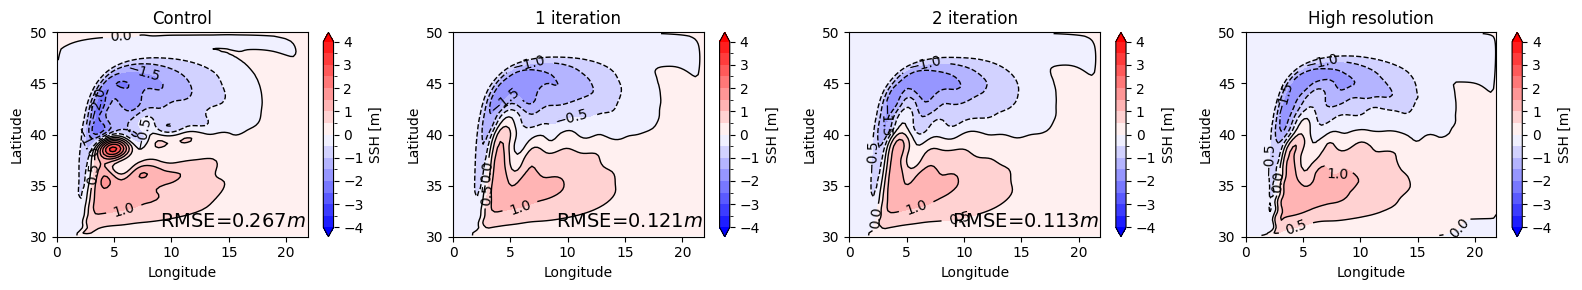

In [311]:
ds.plot_ssh(['ZB-stress-pass-4-sel-1-Cs-0.06-ZB-0.0', 'calibration-Cs-0.05-ZB-1.0', 'calibration-Cs-0.043-ZB-0.88', 'R64_R4'],
           labels=['Control', '1 iteration', '2 iteration', 'High resolution'])

In [312]:
du = np.array([0.043, 0.88]) - np.array([0.05, 1.0])

In [313]:
dy = (ds['calibration-Cs-0.043-ZB-0.88'].ssh_mean - ds['calibration-Cs-0.05-ZB-1.0'].ssh_mean).values.ravel()

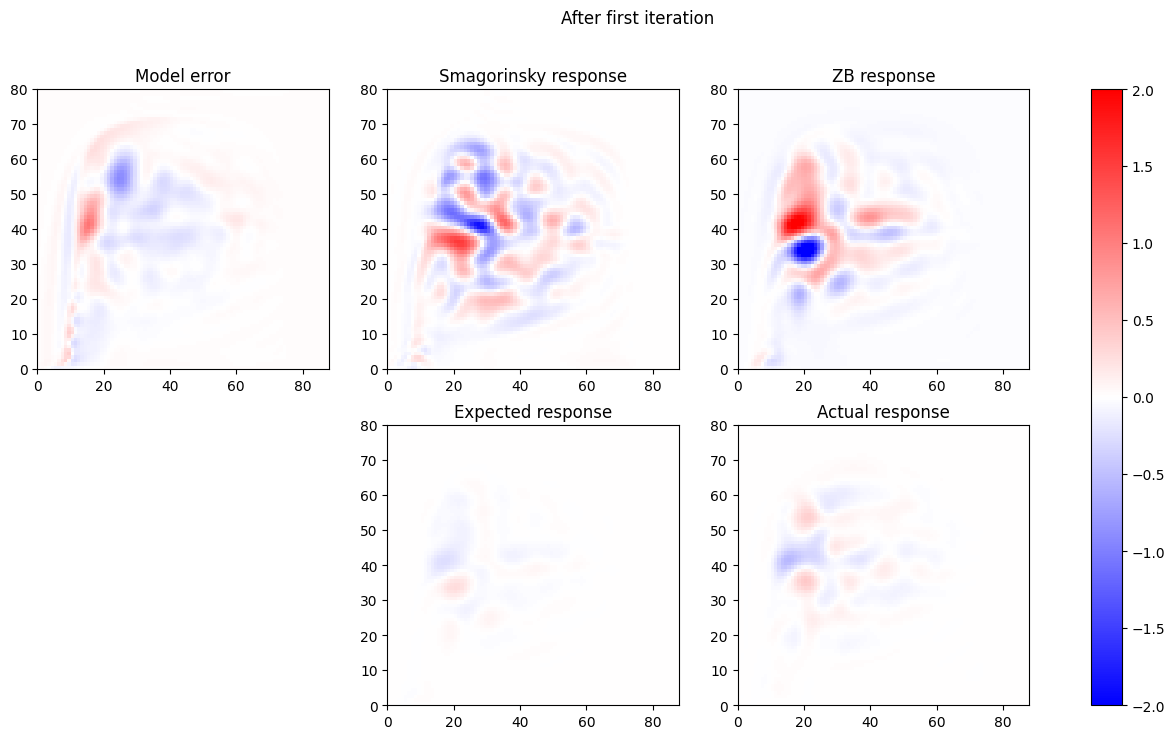

In [314]:
plt.figure(figsize=(16,8))
kw = dict(vmin=-2,vmax=2,cmap='bwr')
plt.subplot(2,3,1)
plt.pcolormesh(error.reshape([80,88]), **kw)
plt.title('Model error')
plt.subplot(2,3,5)
plt.pcolormesh((np.linalg.pinv(H)@du).reshape([80,88]), **kw)
plt.title('Expected response')
plt.subplot(2,3,6)
plt.pcolormesh(dy.reshape([80,88]), **kw)
plt.title('Actual response')

plt.subplot(2,3,2)
plt.pcolormesh(0.2*np.linalg.pinv(H)[:,0].reshape([80,88]), **kw)
plt.title('Smagorinsky response')
plt.subplot(2,3,3)
plt.pcolormesh(np.linalg.pinv(H)[:,1].reshape([80,88]), **kw)
plt.title('ZB response')

plt.suptitle('After first iteration')


plt.colorbar(ax=plt.gcf().axes)

In [315]:
print(np.linalg.norm(np.outer(du, dy) / np.dot(dy,dy)))
print(np.linalg.norm(np.outer(du-H@dy, dy) / np.dot(dy,dy)))
print(np.linalg.norm(H))

0.023608889051287378
0.004308945938497377
0.04885428740675261


In [316]:
H += np.outer(du-H@dy, dy) / np.dot(dy,dy)

In [317]:
print('Singular values of H', np.linalg.svd(H).S)

Singular values of H [0.04559296 0.00981717]


In [318]:
error = (ds['calibration-Cs-0.043-ZB-0.88'].ssh_mean - ds['R64_R4'].ssh_mean).values.ravel()

In [319]:
u = np.array([0.043, 0.88])

In [320]:
u = u - H@error

In [321]:
# We retain two main digits
print(round(u[0],3))
print(round(u[1],2))

0.039
0.9


# A posteriori analysis of iteration

In [322]:
print('Initial loss:', np.sqrt(np.mean(error**2)))
expected_error = error - np.linalg.pinv(H) @ H @ error
print('Expected loss:', np.sqrt(np.mean(expected_error**2)))

Initial loss: 0.11302199
Expected loss: 0.1127763570167582


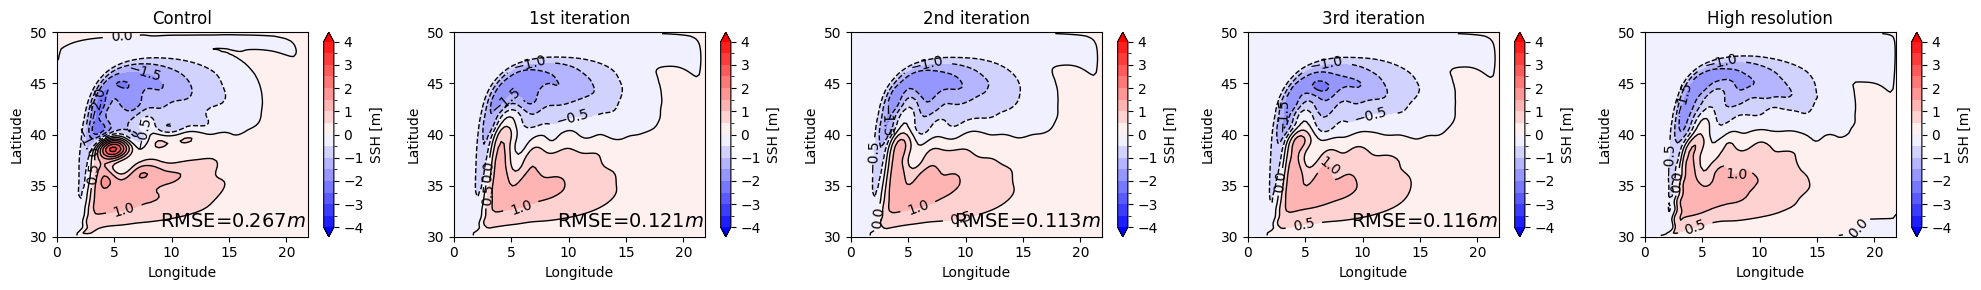

In [323]:
ds.plot_ssh(['ZB-stress-pass-4-sel-1-Cs-0.06-ZB-0.0', 'calibration-Cs-0.05-ZB-1.0', 'calibration-Cs-0.043-ZB-0.88',
             'calibration-Cs-0.039-ZB-0.9', 'R64_R4'],
           labels=['Control', '1st iteration', '2nd iteration', '3rd iteration', 'High resolution'])

In [324]:
du = np.array([0.039, 0.9]) - np.array([0.043, 0.88])

In [325]:
dy = (ds['calibration-Cs-0.039-ZB-0.9'].ssh_mean - ds['calibration-Cs-0.043-ZB-0.88'].ssh_mean).values.ravel()

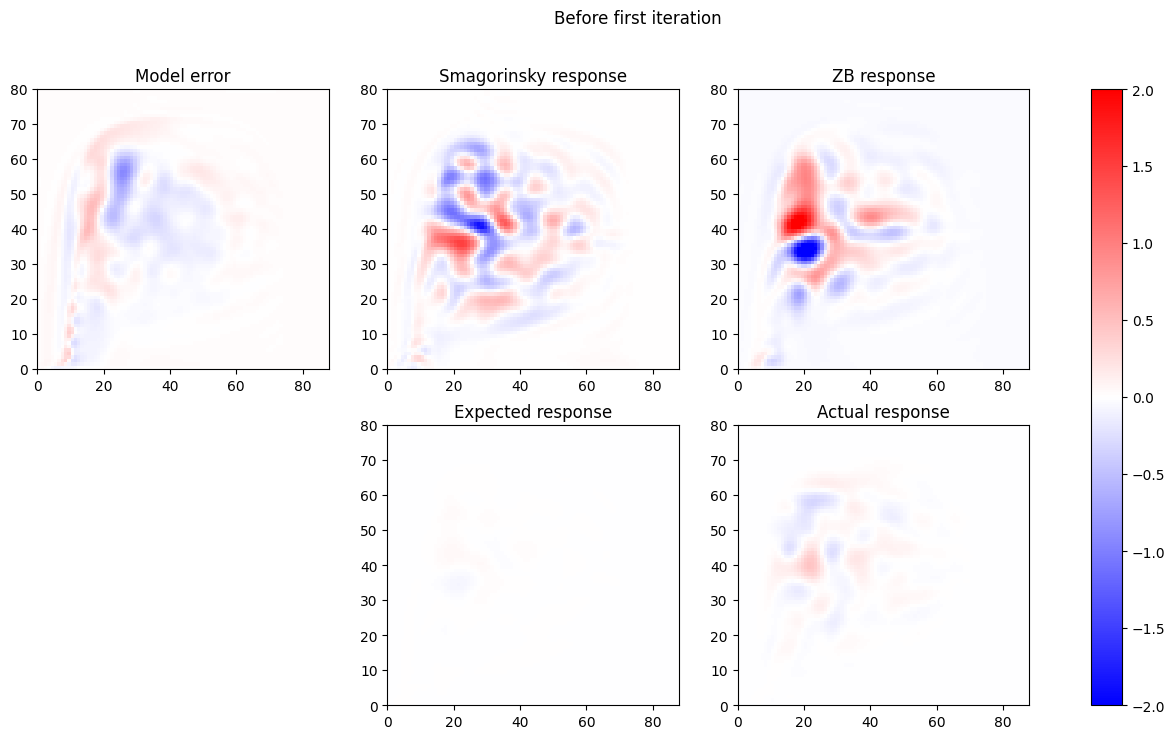

In [326]:
plt.figure(figsize=(16,8))
kw = dict(vmin=-2,vmax=2,cmap='bwr')
plt.subplot(2,3,1)
plt.pcolormesh(error.reshape([80,88]), **kw)
plt.title('Model error')
plt.subplot(2,3,5)
plt.pcolormesh((np.linalg.pinv(H)@du).reshape([80,88]), **kw)
plt.title('Expected response')
plt.subplot(2,3,6)
plt.pcolormesh(dy.reshape([80,88]), **kw)
plt.title('Actual response')

plt.subplot(2,3,2)
plt.pcolormesh(0.2*np.linalg.pinv(H)[:,0].reshape([80,88]), **kw)
plt.title('Smagorinsky response')
plt.subplot(2,3,3)
plt.pcolormesh(np.linalg.pinv(H)[:,1].reshape([80,88]), **kw)
plt.title('ZB response')

plt.suptitle('Before first iteration')


plt.colorbar(ax=plt.gcf().axes)

In [327]:
print(np.linalg.norm(np.outer(du, dy) / np.dot(dy,dy)))
print(np.linalg.norm(np.outer(10*du-H@dy, dy) / np.dot(dy,dy)))
print(np.linalg.norm(np.outer(H@dy, dy) / np.dot(dy,dy)))
print(np.linalg.norm(H))

0.0047973235783250485
0.03864585553290163
0.010860586150882113
0.04663791255987131


In [328]:
H += np.outer(du-H@dy, dy) / np.dot(dy,dy)
#H = np.outer(du, dy) / np.dot(dy,dy)

# Notes
It looks like matrix H memorizes all response patterns and maps them to the parameter space without issues
Also probably adding additional directions to H is not a problem if a response pattern random (i.e. a part of variability), because these patterns do not project onto physically-relevant response patters, and different with each realization of the online run. So, their scalar product is always close to zero.

In [329]:
print(H@J[:,0]*0.03)
print(H@J[:,1])
print(H@dy-du)
print(du)

[0.02750744 0.0063712 ]
[-0.00356964  0.76676733]
[9.65751280e-10 1.40784542e-09]
[-0.004  0.02 ]


In [330]:
print('Singular values of H', np.linalg.svd(H).S)

Singular values of H [0.04456833 0.0096861 ]


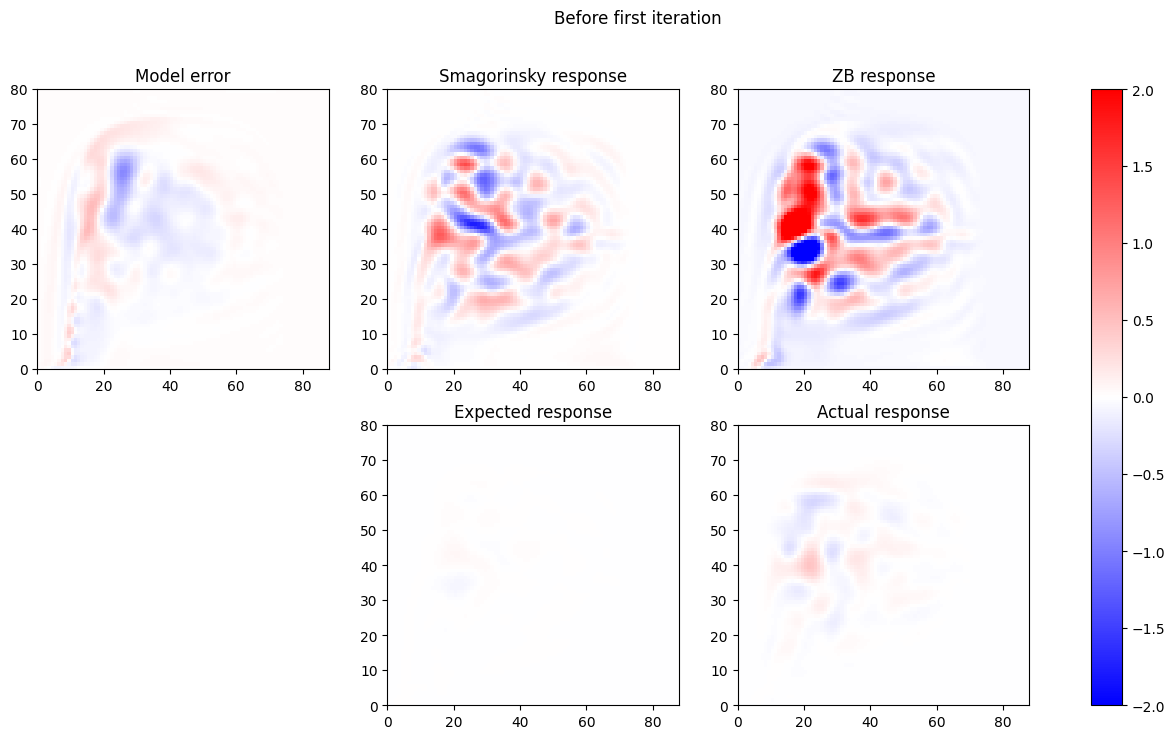

In [338]:
plt.figure(figsize=(16,8))
kw = dict(vmin=-2,vmax=2,cmap='bwr')
plt.subplot(2,3,1)
plt.pcolormesh(error.reshape([80,88]), **kw)
plt.title('Model error')
plt.subplot(2,3,5)
plt.pcolormesh((np.linalg.pinv(H)@du).reshape([80,88]), **kw)
plt.title('Expected response')
plt.subplot(2,3,6)
plt.pcolormesh(dy.reshape([80,88]), **kw)
plt.title('Actual response')

plt.subplot(2,3,2)
plt.pcolormesh(2000*H[0,:].reshape([80,88]), **kw)
plt.title('Smagorinsky response')
plt.subplot(2,3,3)
plt.pcolormesh(1000*H[1,:].reshape([80,88]), **kw)
plt.title('ZB response')

plt.suptitle('Before first iteration')


plt.colorbar(ax=plt.gcf().axes)

# Check different initial points

In [27]:
def Broyden_iteration(seed=0, 
                      Cs_grid = np.array([0.01, 0.03, 0.06]),
                      ZB_grid = [round(x,2) for x in np.arange(0,3.1,0.1)],
                      ZB_step=(0.5,1.5), 
                      Cs_step=(0.02,0.03,0.05)):
    '''
    This function randomly samples control simulation
    within specified grid,
    randomly perturbes parameter in a specified range,
    estimates Jacobian and makes a prediction of parameters using
    one iteration of Broyden method
    '''
    rng = np.random.default_rng(seed=seed)
    
    # Generate initial point
    ZB0 = rng.choice(ZB_grid)
    Cs0 = rng.choice(Cs_grid)

    # Generate perturbations
    ZB = round(ZB0 + rng.choice([-1,1]) * rng.uniform(*ZB_step),1)
    Cs = round(Cs0 + rng.choice([-1,1]) * rng.choice(Cs_step),2)

    # Check that all experiments exist
    try:
        error_ssh(f'ZB-stress-pass-4-sel-1-Cs-{Cs0}-ZB-{ZB0}')
    except:
        return

    try:
        error_ssh(f'ZB-stress-pass-4-sel-1-Cs-{Cs}-ZB-{ZB0}')
    except:
        return

    try:
        error_ssh(f'ZB-stress-pass-4-sel-1-Cs-{Cs0}-ZB-{ZB}')
    except:
        return


    J = np.zeros((7040,2))

    J[:,0] = ((ds[f'ZB-stress-pass-4-sel-1-Cs-{Cs}-ZB-{ZB0}'].ssh_mean - ds[f'ZB-stress-pass-4-sel-1-Cs-{Cs0}-ZB-{ZB0}'].ssh_mean) / (Cs-Cs0)).values.ravel()
    J[:,1] = ((ds[f'ZB-stress-pass-4-sel-1-Cs-{Cs0}-ZB-{ZB}'].ssh_mean - ds[f'ZB-stress-pass-4-sel-1-Cs-{Cs0}-ZB-{ZB0}'].ssh_mean) / (ZB-ZB0)).values.ravel()

    plt.figure(figsize=(12,4))
    kw = dict(vmin=-2,vmax=2,cmap='bwr')
    plt.subplot(1,2,1)
    plt.pcolormesh(0.2*J[:,0].reshape([80,88]), **kw)
    plt.title('Smagorinsky response from J')
    plt.subplot(1,2,2)
    plt.pcolormesh(J[:,1].reshape([80,88]), **kw)
    plt.title('ZB response from J')
    
    plt.suptitle(f'Initialized Jacobian at Cs={Cs0}, ZB={ZB0}\ncorr(J_0,J)={np.diag(J0.T@J) / np.sqrt(np.diag(J.T@J) * np.diag(J0.T@J0))}', y=1.1)
    
    
    plt.colorbar(ax=plt.gcf().axes)

    error = (ds[f'ZB-stress-pass-4-sel-1-Cs-{Cs0}-ZB-{ZB0}'].ssh_mean - ds['R64_R4'].ssh_mean).values.ravel()

    H = np.linalg.pinv(J)

    u0 = np.array([Cs0, ZB0])
    du = - H@error
    u = u0 + du
    u[0] = round(u[0],3)
    u[1] = round(u[1],2)
    du = u - u0

    initial_error = round(np.sqrt(np.mean(error**2)),3)
    expected_error = error + np.linalg.pinv(H) @ du
    expected_error = round(np.sqrt(np.mean(expected_error**2)),3)
    J = np.linalg.pinv(H)
    J_error_correlation = J.T@error / np.sqrt(np.diag(J.T@J) * np.dot(error,error))
    
    print(f'Initial: Cs={Cs0} and ZB={ZB0}, perturbed: Cs={Cs}, ZB={ZB}')
    print(f'1st iteration: Cs={u[0]}, ZB={u[1]}, initial/expected error: {initial_error}/{expected_error}, J-error correlation: {J_error_correlation}')
    print('Singular values of H', np.linalg.svd(H).S)

    try:
        dy = (ds[f'calibration-Cs-{u[0]}-ZB-{u[1]}'].ssh_mean - ds[f'ZB-stress-pass-4-sel-1-Cs-{Cs0}-ZB-{ZB0}'].ssh_mean).values.ravel()
    except:
        return

    H += np.outer(du-H@dy, dy) / np.dot(dy,dy)

    error = (ds[f'calibration-Cs-{u[0]}-ZB-{u[1]}'].ssh_mean - ds['R64_R4'].ssh_mean).values.ravel()
    du =  - H@error
    u_new = u + du
    u_new[0] = round(u_new[0],3)
    u_new[1] = round(u_new[1],2)
    du = u_new - u

    initial_error = round(np.sqrt(np.mean(error**2)),3)
    expected_error = error + np.linalg.pinv(H) @ du
    expected_error = round(np.sqrt(np.mean(expected_error**2)),3)
    J = np.linalg.pinv(H)
    J_error_correlation = J.T@error / np.sqrt(np.diag(J.T@J) * np.dot(error,error))
    
    print(f'2nd iteration: Cs={u_new[0]}, ZB={u_new[1]}, initial/expected error: {initial_error}/{expected_error}, J-error correlation: {J_error_correlation}')
    print('Singular values of H', np.linalg.svd(H).S)

item not found
item not found
item not found
item not found
Initial: Cs=0.06 and ZB=2.0, perturbed: Cs=0.09, ZB=1.0
1st iteration: Cs=0.06, ZB=1.14, initial/expected error: 0.19599999487400055/0.116, J-error correlation: [-0.6521535   0.80482333]
Singular values of H [0.11115067 0.00366181]
2nd iteration: Cs=0.042, ZB=0.79, initial/expected error: 0.13099999725818634/0.126, J-error correlation: [0.09736808 0.06476995]
Singular values of H [0.12383844 0.00346934]
item not found
item not found
item not found
item not found
item not found
item not found
Initial: Cs=0.06 and ZB=0.4, perturbed: Cs=0.03, ZB=1.6
1st iteration: Cs=0.029, ZB=0.81, initial/expected error: 0.2160000056028366/0.106, J-error correlation: [ 0.8394089  -0.81668841]
Singular values of H [0.09836942 0.00327352]
2nd iteration: Cs=0.018, ZB=0.5, initial/expected error: 0.12600000202655792/0.117, J-error correlation: [-0.19123524  0.32844977]
Singular values of H [0.09162033 0.00299257]
item not found
item not found
item 

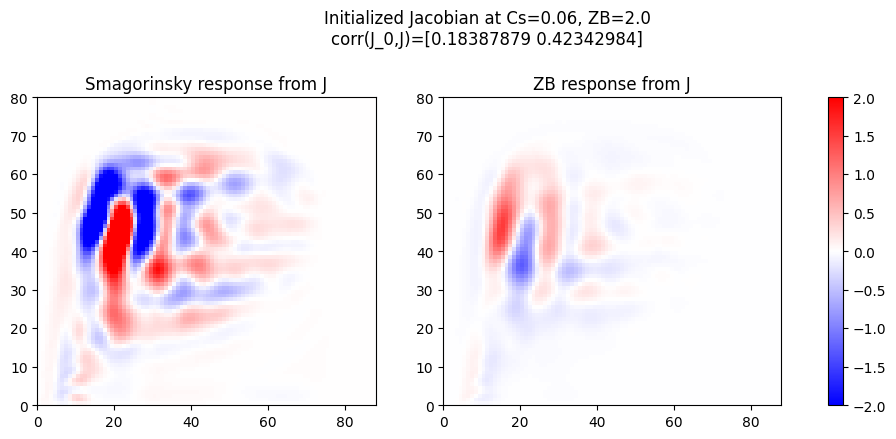

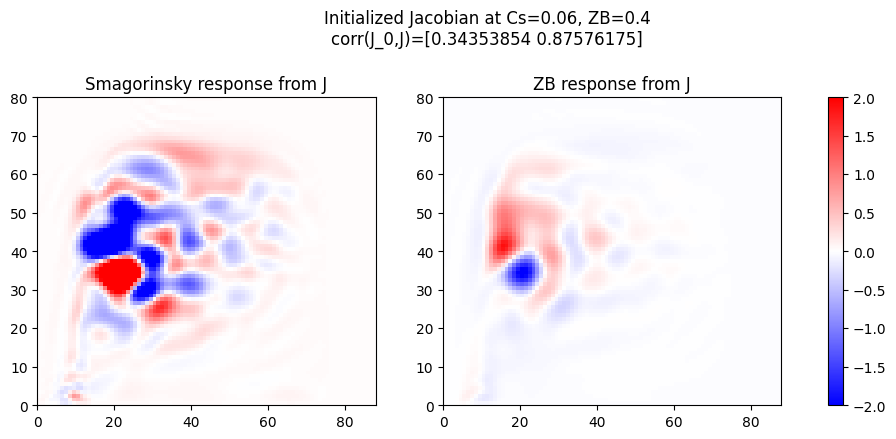

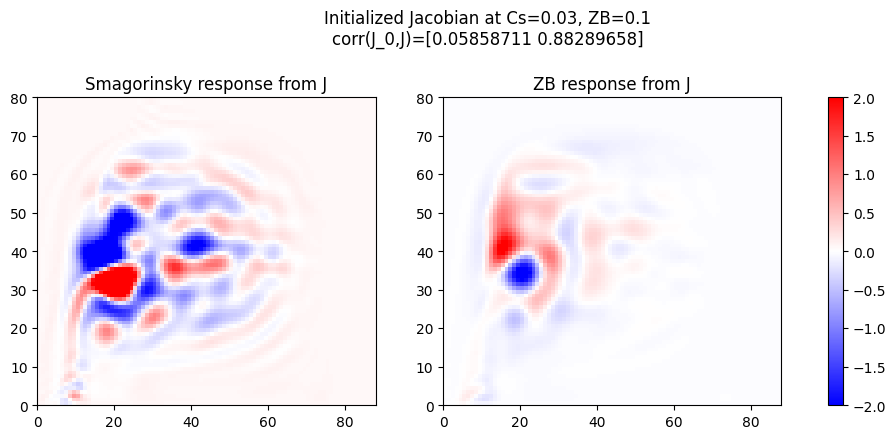

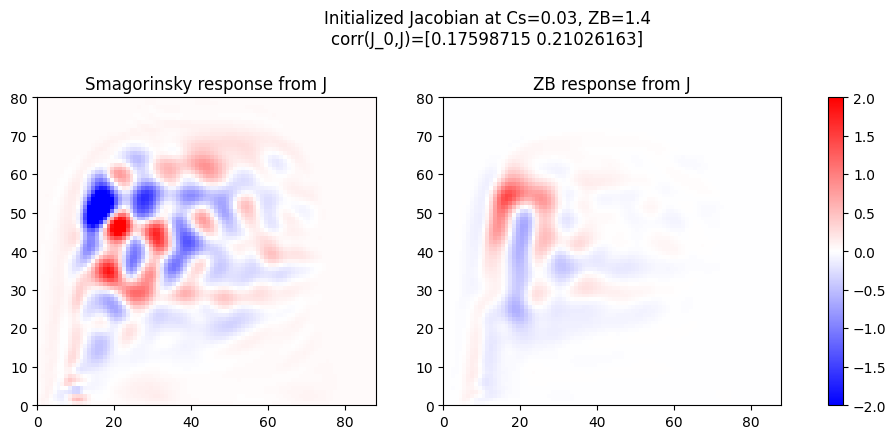

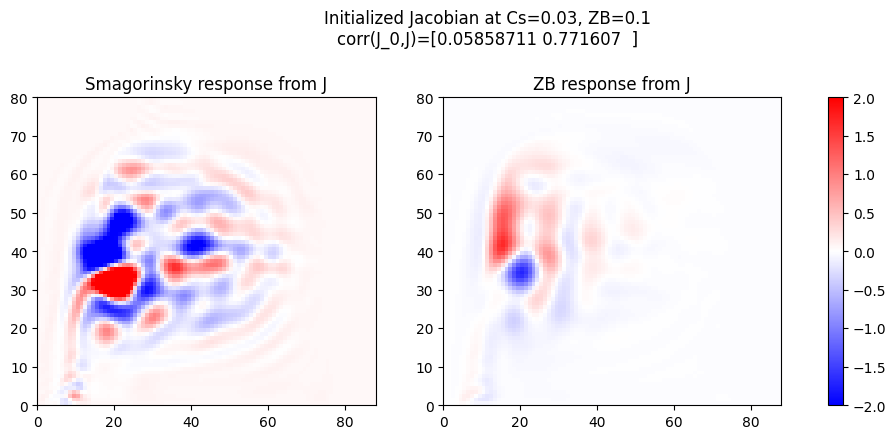

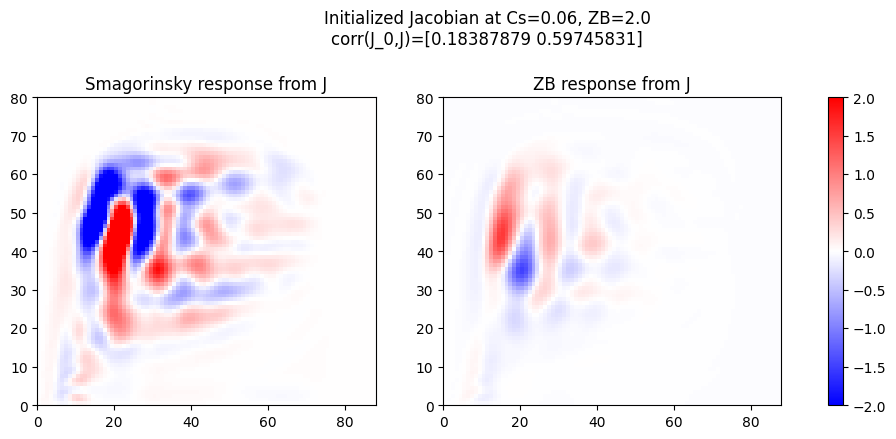

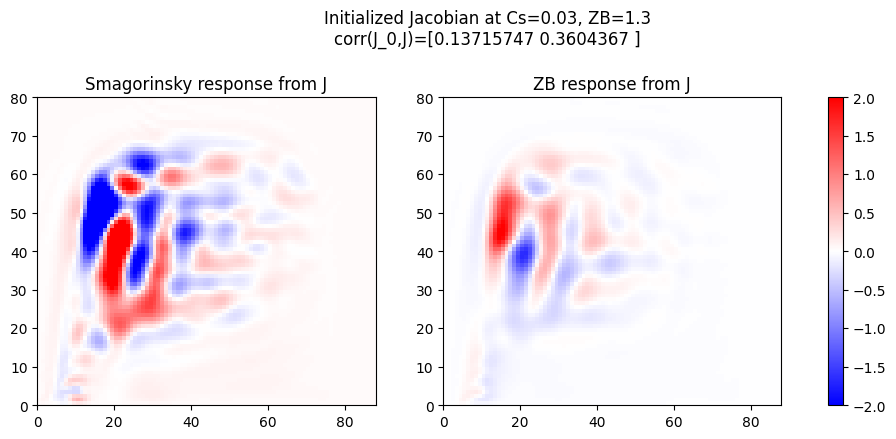

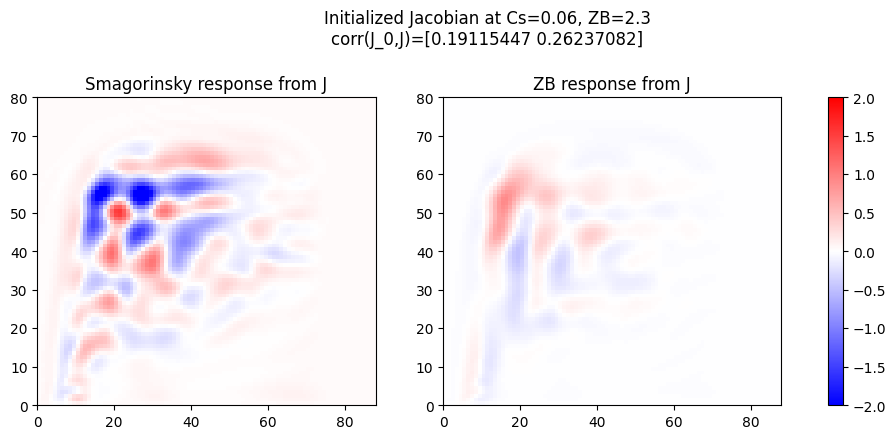

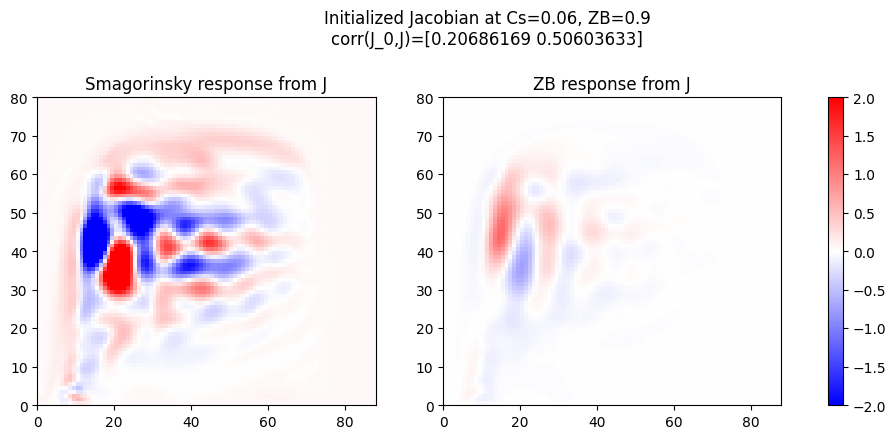

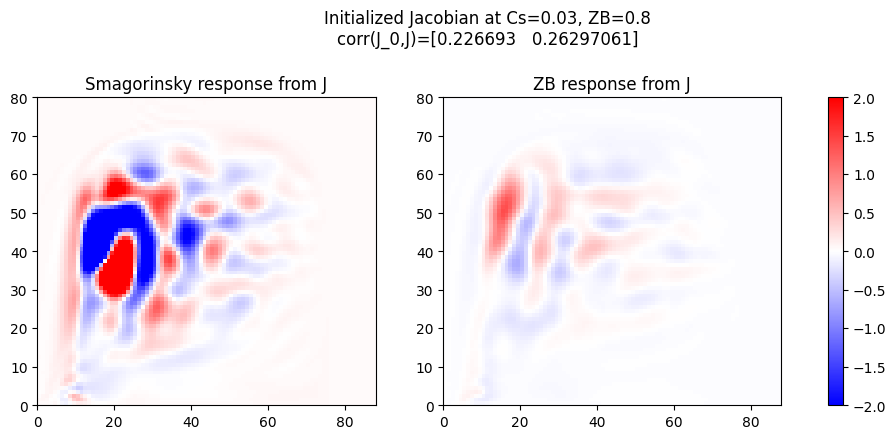

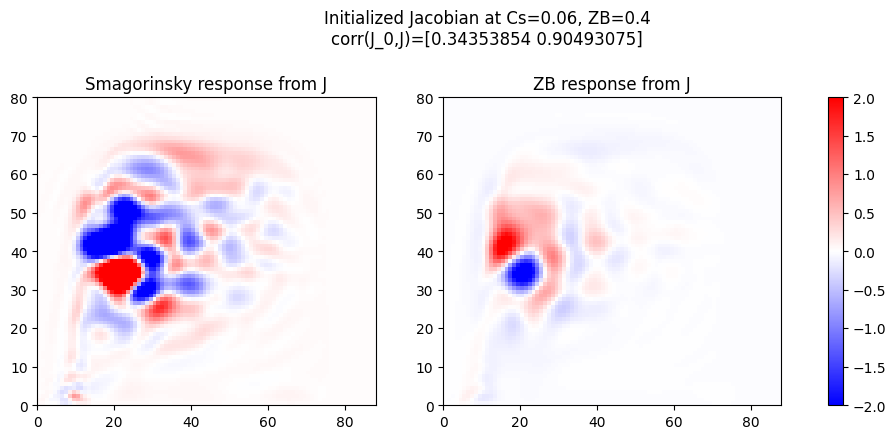

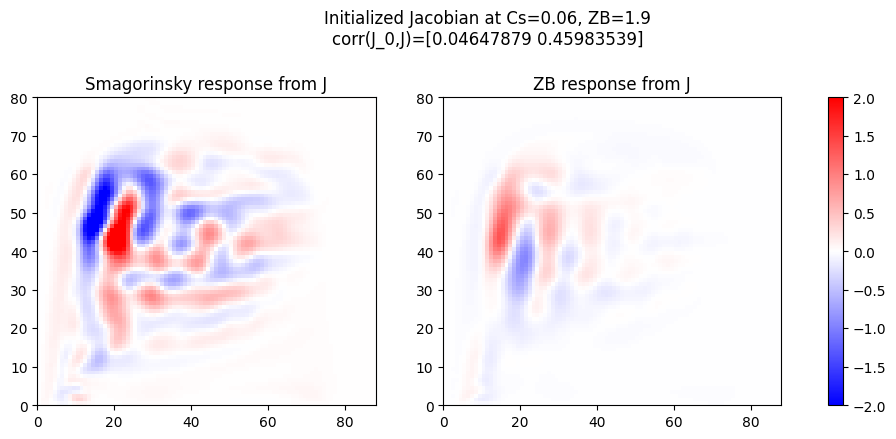

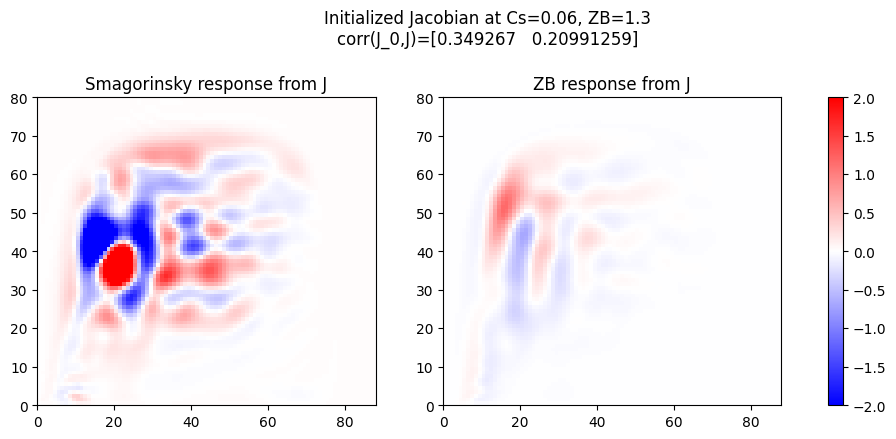

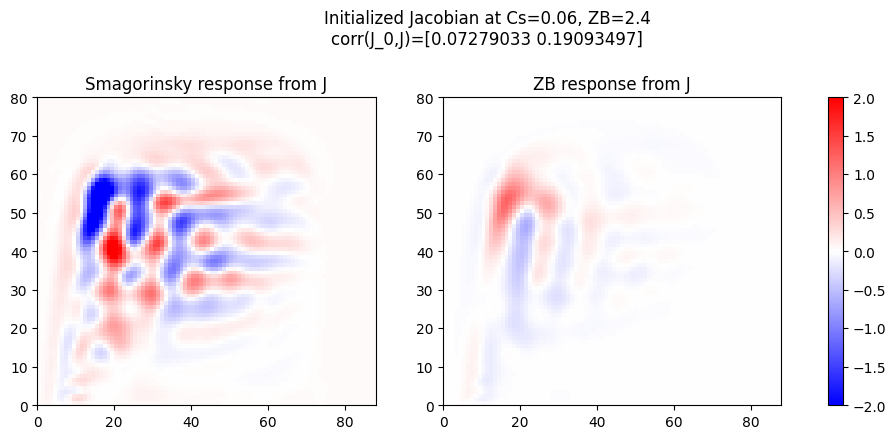

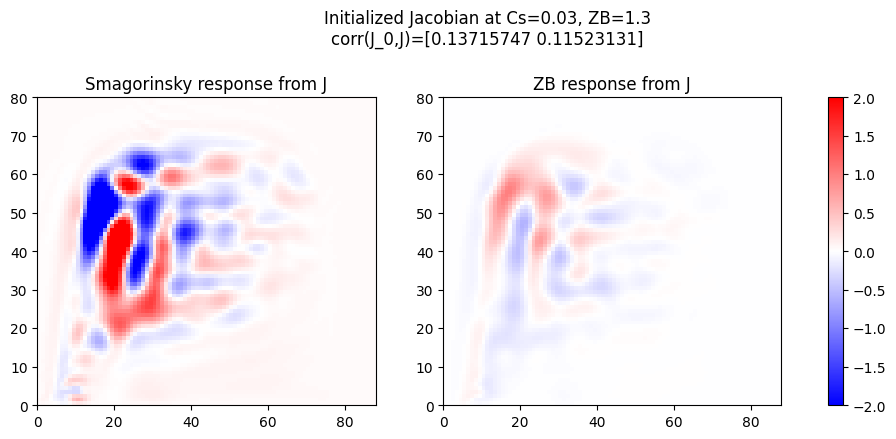

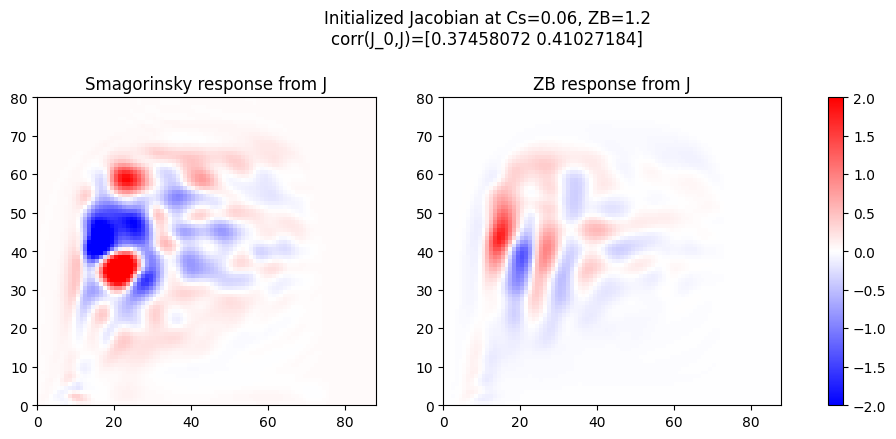

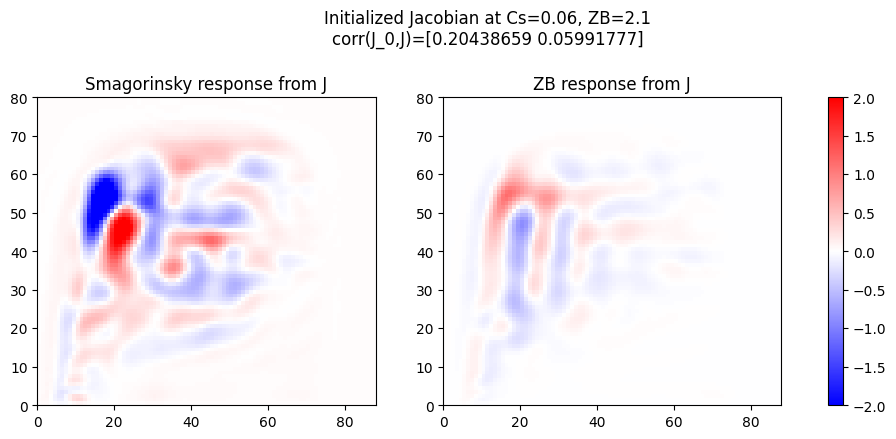

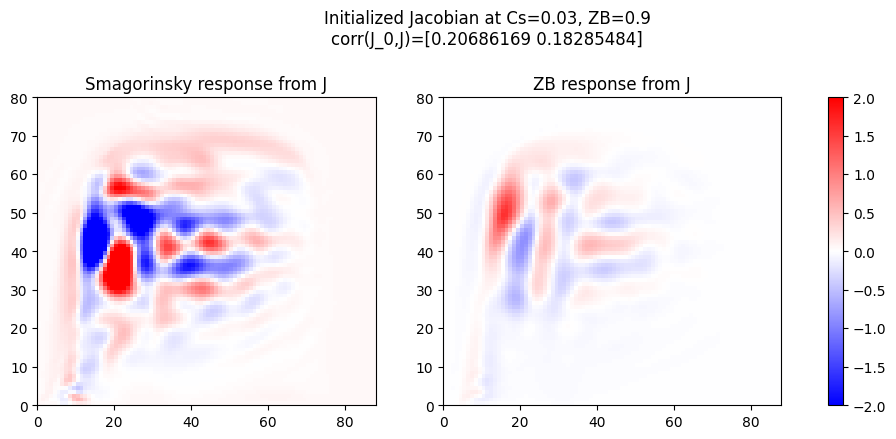

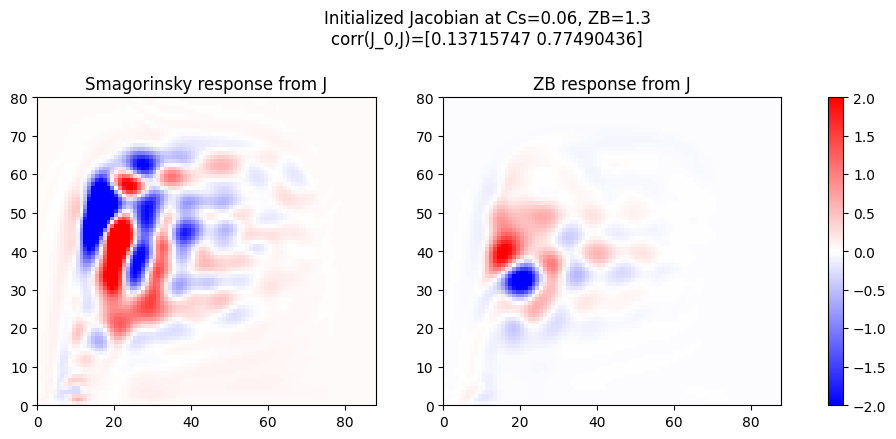

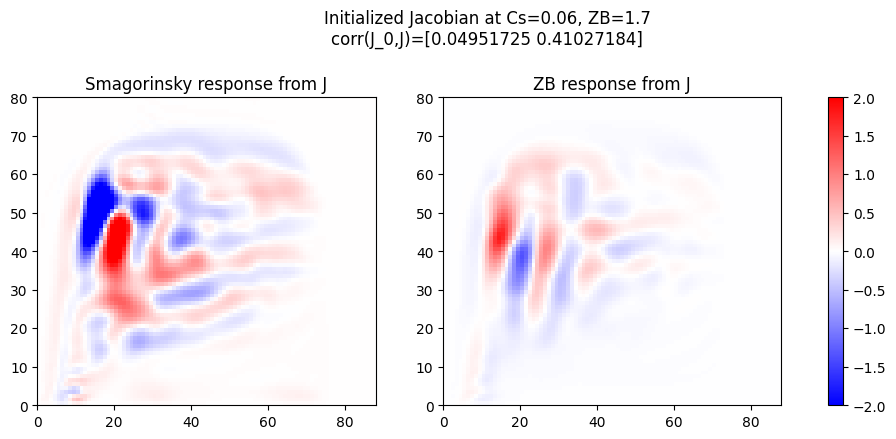

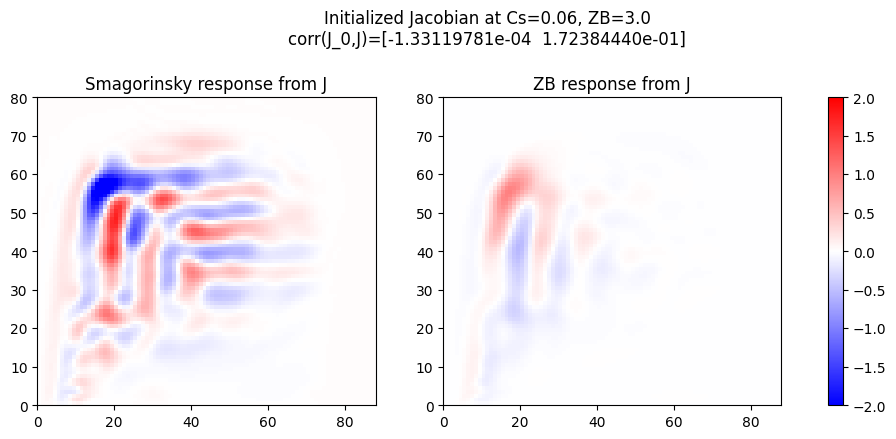

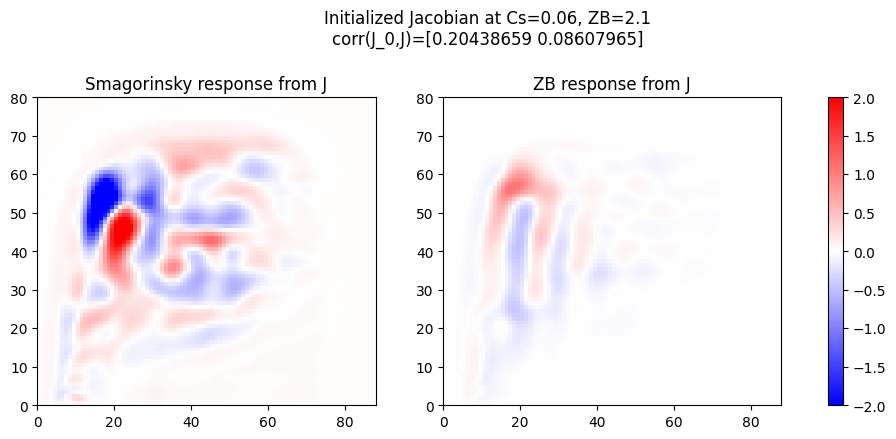

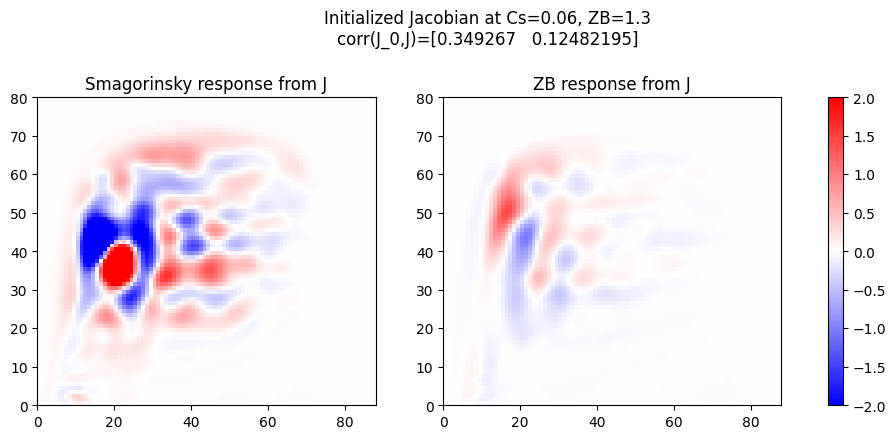

In [29]:
for seed in range(200):
    Broyden_iteration(seed=seed)

In [207]:
n=10
def ej(j):
    x = np.zeros(n)
    x[j]=1
    return x

In [221]:
A = np.outer(np.array([1,0]),ej(0)) + np.outer(np.array([0,1]),ej(1)) + np.outer(np.array([100000,100000]),ej(2))
print(A)
print(np.linalg.pinv(A))

[[1.e+00 0.e+00 1.e+05 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00]
 [0.e+00 1.e+00 1.e+05 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00]]
[[ 5.e-01 -5.e-01]
 [-5.e-01  5.e-01]
 [ 5.e-06  5.e-06]
 [ 0.e+00  0.e+00]
 [ 0.e+00  0.e+00]
 [ 0.e+00  0.e+00]
 [ 0.e+00  0.e+00]
 [ 0.e+00  0.e+00]
 [ 0.e+00  0.e+00]
 [ 0.e+00  0.e+00]]
